# Sensor Data Exploration
This notebook provides a concise workflow for exploring multiple sensor datasets with pandas. It covers:

- Loading sensor files (CSV/JSON) and combining them into a single DataFrame.
- Parsing and aligning timestamps, setting a datetime index.
- Cleaning steps: handling missing values, duplicates, outliers, and unit/column harmonization.
- Quick descriptive statistics, group summaries by sensor/type, and checks for data quality.
- Time-series operations: resampling, rolling aggregates, and interpolation to common frequencies.
- Visualizations: time series plots, distributions, correlation matrices, and simple anomaly detection.
- Exporting cleaned datasets and prepared features for downstream modeling or reporting.

Expected inputs: one or more files containing timestamp, sensor_id (or similar), and measurement columns.  
Outputs: a cleaned, merged DataFrame, summary tables, and plots to guide further analysis.

In [12]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

#Declare the path for datasets
data_path = '../data'

In [17]:
#Display all files
files = os.listdir(f"{data_path}/raw/")
files

['2026_06_08_aluminum_01.csv',
 '2026_06_08_aluminum_02.csv',
 '2026_06_08_aluminum_03.csv',
 '2026_06_08_corkboard_01.csv',
 '2026_06_08_corkboard_02.csv',
 '2026_06_08_corkboard_03.csv',
 '2026_06_08_glass_01.csv',
 '2026_06_08_glass_02.csv',
 '2026_06_08_glass_03.csv',
 '2026_06_08_pdms_01.csv',
 '2026_06_08_pdms_02.csv',
 '2026_06_08_pdms_03.csv',
 '2026_06_08_steel_01.csv',
 '2026_06_08_steel_02.csv',
 '2026_06_08_steel_03.csv']

In [8]:
al1 = pd.read_csv(f"{data_path}/raw/2026_06_08_aluminum_01.csv").dropna()
al1.head()

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,aluminum,1.0,0.00939,0.00066,0.000699
1,2.0,aluminum,1.0,0.10066,0.00066,0.000699
2,3.0,aluminum,1.0,0.20070,0.00066,0.000699
3,4.0,aluminum,1.0,0.30070,0.00066,0.000699
4,5.0,aluminum,1.0,0.40070,0.00066,0.000699


In [10]:
al1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      148 non-null    float64
 1   Sample     148 non-null    object 
 2   Trial      148 non-null    float64
 3   Time       148 non-null    float64
 4   Primary    148 non-null    float64
 5   Secondary  148 non-null    float64
dtypes: float64(5), object(1)
memory usage: 8.1+ KB


1. Plot the sensor data

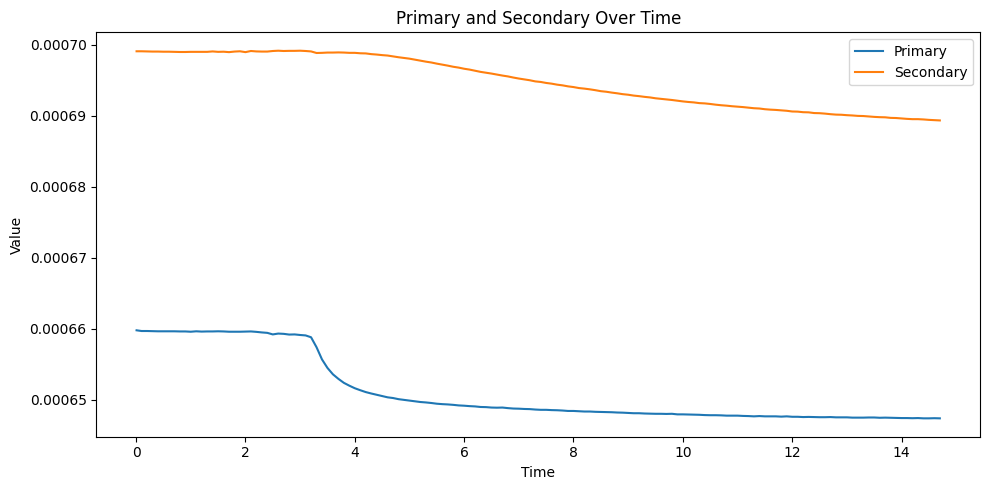

In [14]:
# Plotting Primary and Secondary Readings Over Time
plt.figure(figsize=(10, 5))
plt.plot(al1['Time'], al1['Primary'], label='Primary')
plt.plot(al1['Time'], al1['Secondary'], label='Secondary')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Primary and Secondary Over Time')
plt.legend()
plt.tight_layout()
plt.show()

Combine all sensor data

In [22]:
data = pd.DataFrame()
for f in files:
    df = pd.read_csv(f"{data_path}/raw/{f}").dropna()
    data = pd.concat([data, df], ignore_index=True)
data['Sample'] = data['Sample'].str.lower()
data

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,aluminum,1.0,0.00939,0.000660,0.000699
1,2.0,aluminum,1.0,0.10066,0.000660,0.000699
2,3.0,aluminum,1.0,0.20070,0.000660,0.000699
3,4.0,aluminum,1.0,0.30070,0.000660,0.000699
4,5.0,aluminum,1.0,0.40070,0.000660,0.000699
...,...,...,...,...,...,...
2864,126.0,steel,3.0,12.50067,0.000648,0.000689
2865,127.0,steel,3.0,12.60067,0.000648,0.000689
2866,128.0,steel,3.0,12.70067,0.000648,0.000689
2867,129.0,steel,3.0,12.80067,0.000648,0.000689


In [23]:
data['Sample'].value_counts()

Sample
corkboard    683
glass        675
pdms         550
steel        497
aluminum     464
Name: count, dtype: int64

In [24]:
materials = list(data['Sample'].unique())
materials

['aluminum', 'corkboard', 'glass', 'pdms', 'steel']

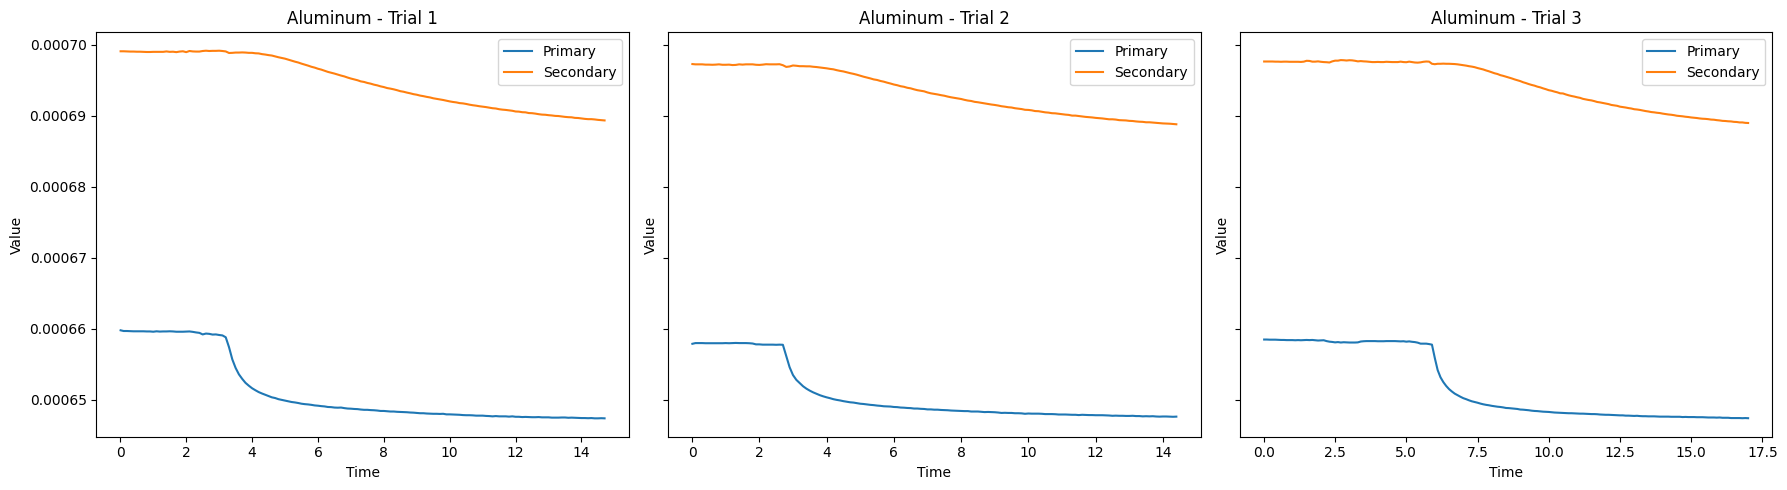

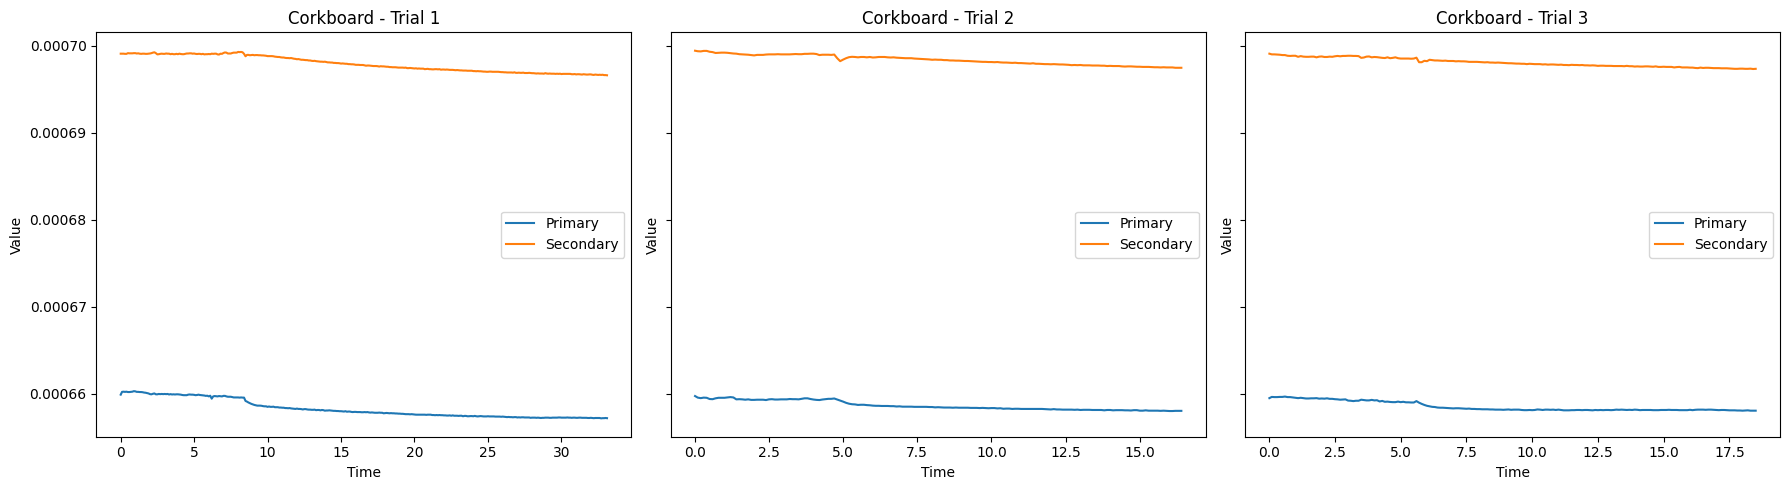

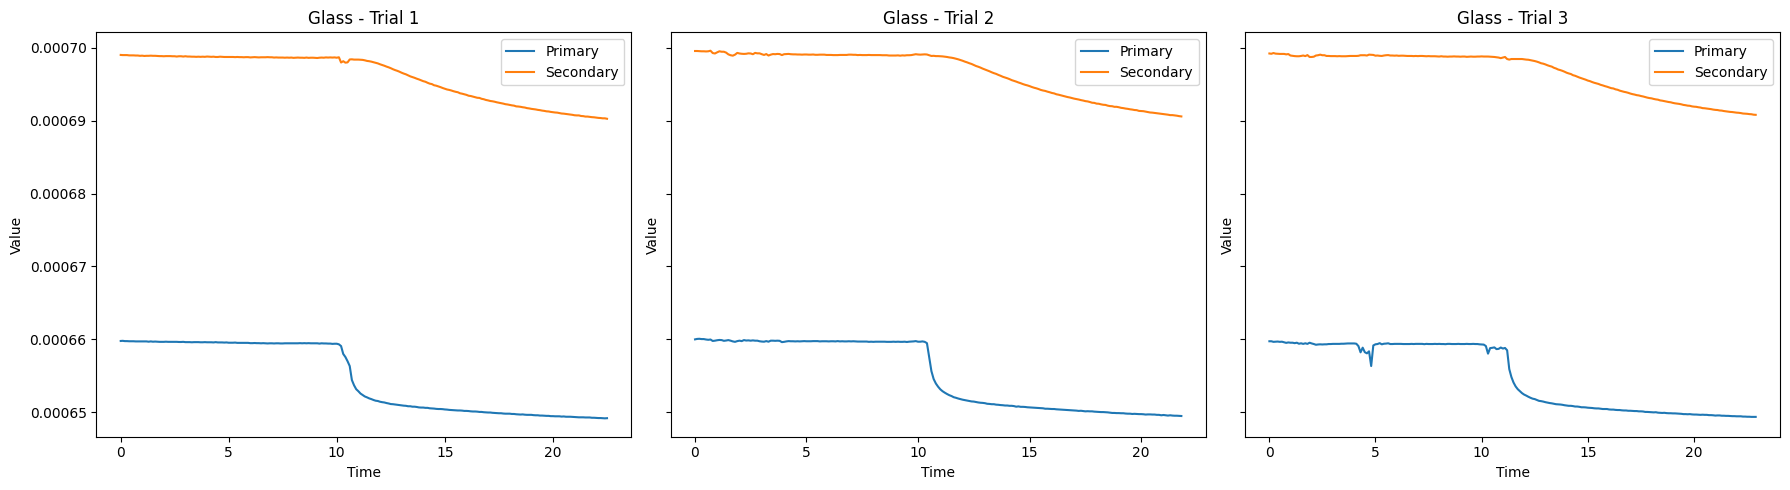

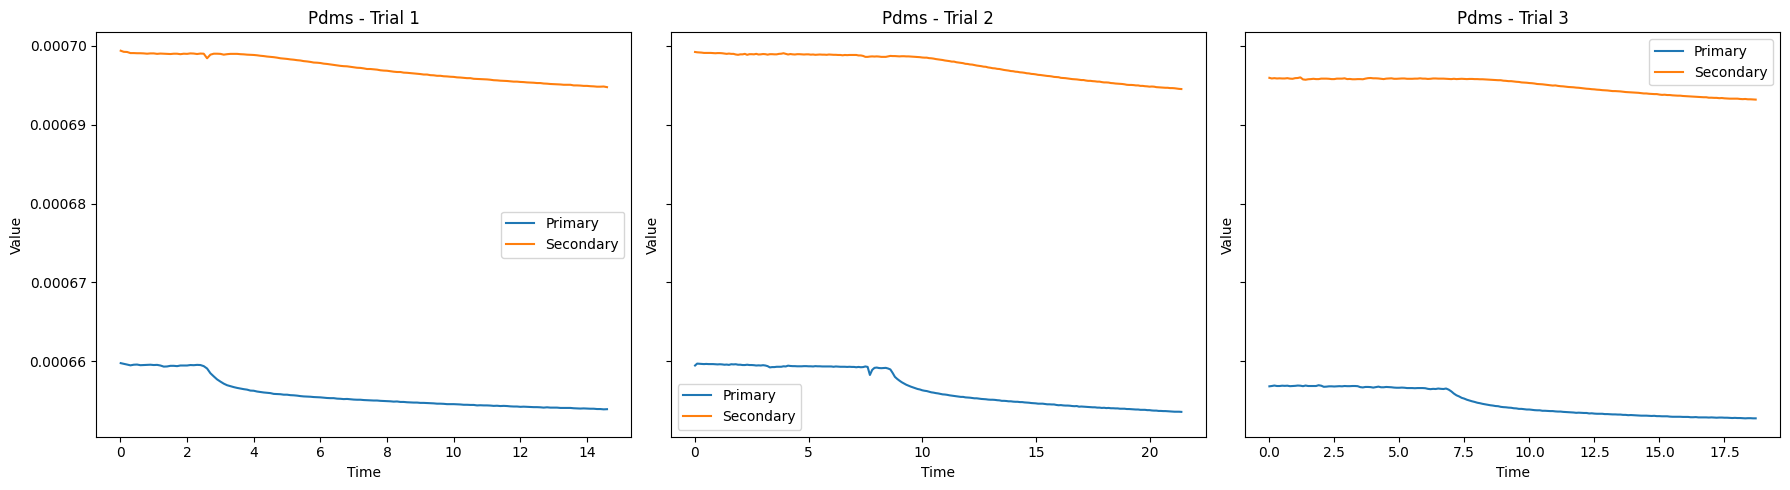

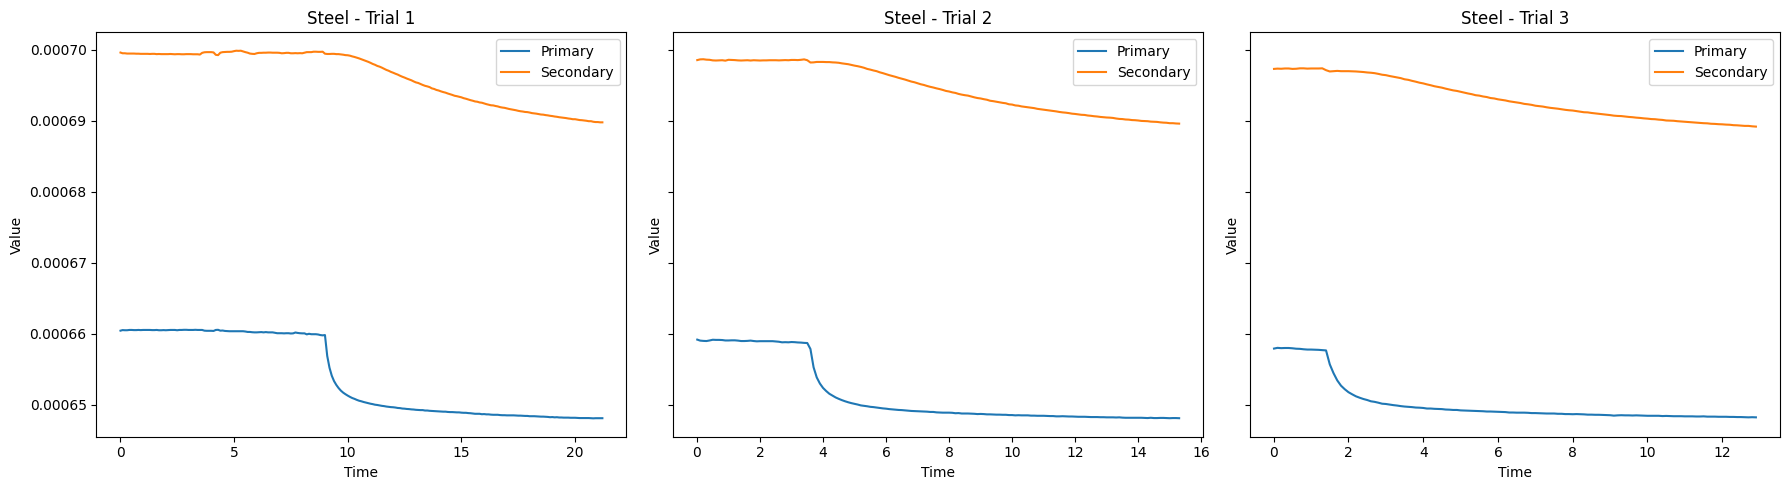

In [27]:
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'], subset['Primary'], label='Primary')
        ax.plot(subset['Time'], subset['Secondary'], label='Secondary')
        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()